Crop Recommendation System

Saving Crop_recommendation.csv to Crop_recommendation (1).csv
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
Accuracy : 0.9931818181818182

Classification Report

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
 

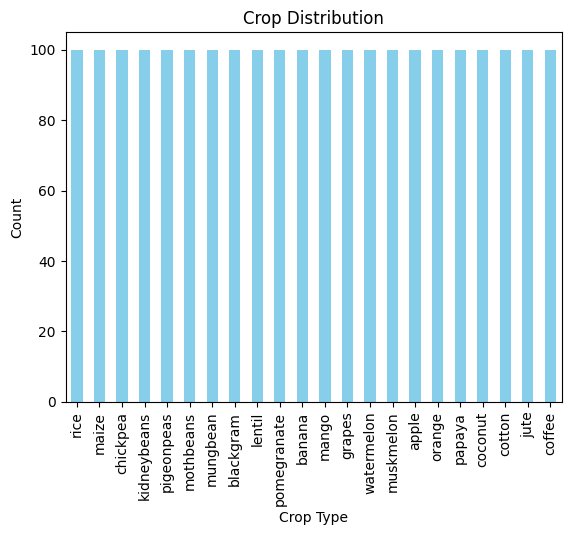

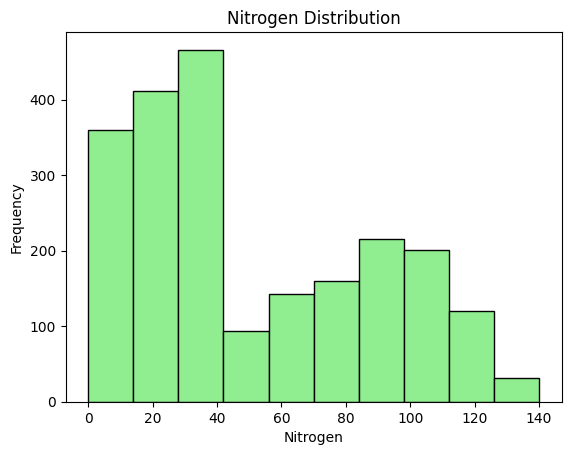

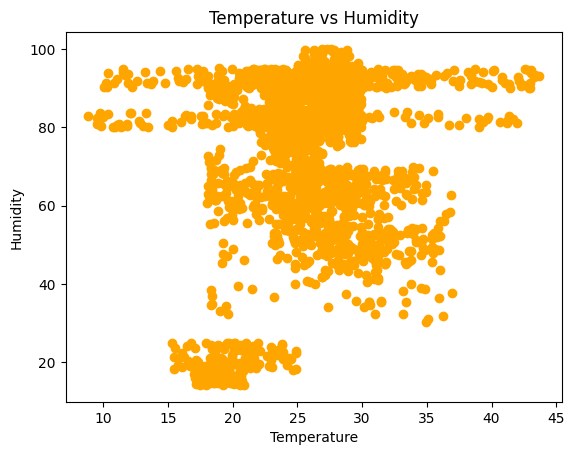

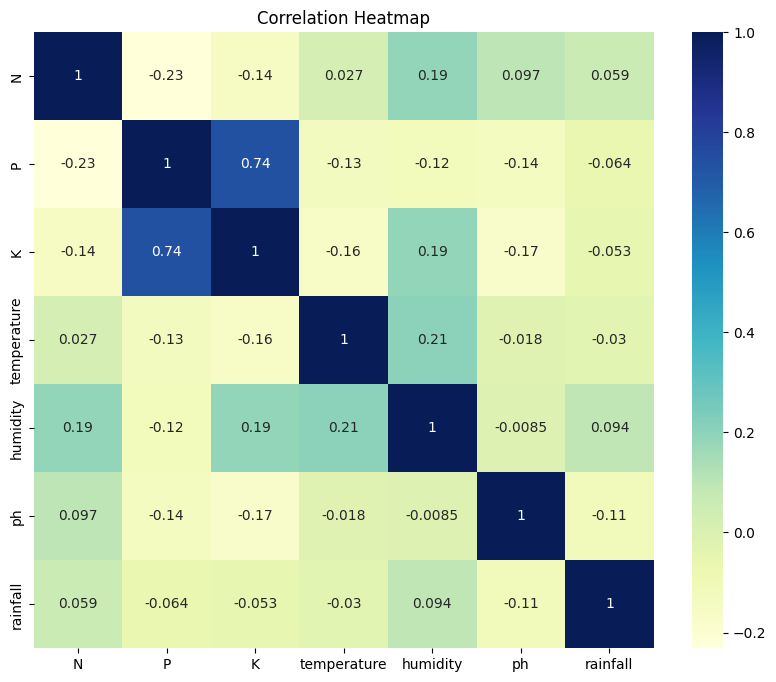

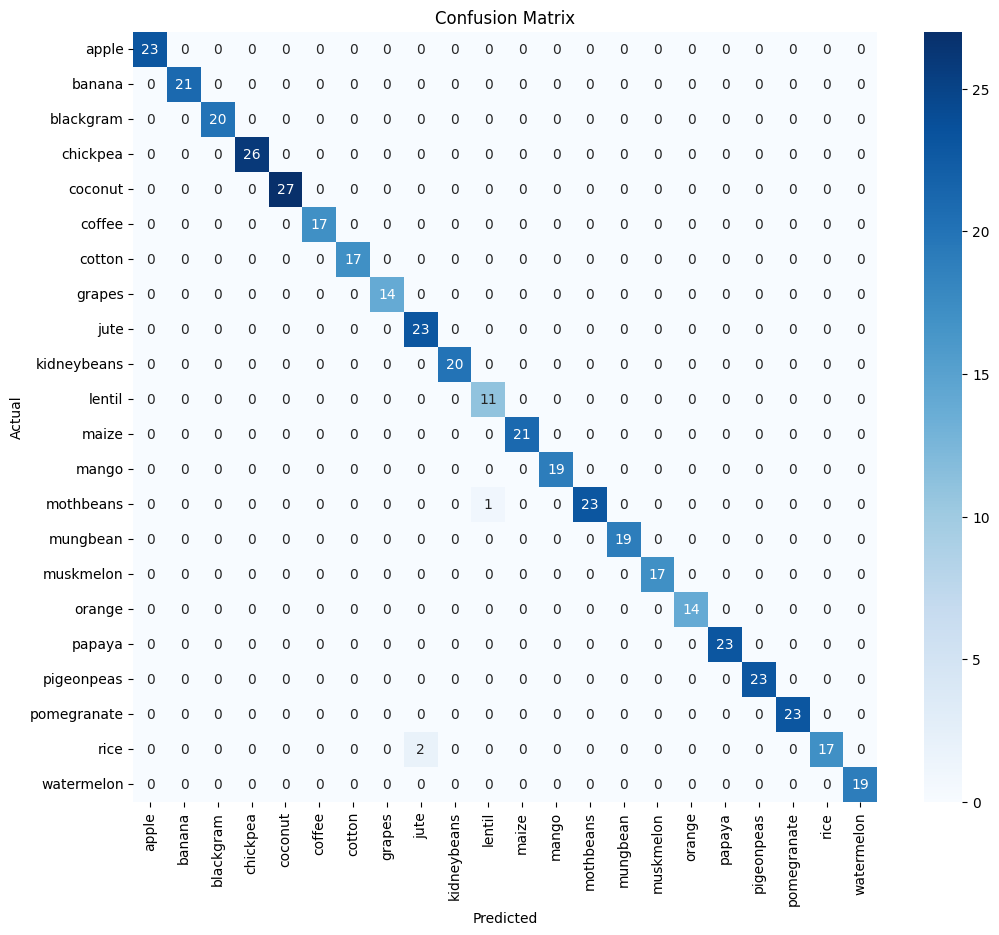

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Upload Dataset
uploaded = files.upload()

# Load Dataset
data = pd.read_csv('Crop_recommendation.csv')

# Display First 5 Rows
print(data.head())

# Feature Selection
X = data.drop('label', axis=1)

y = data['label']

# Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred))

# Crop Distribution Graph
data['label'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Crop Distribution")

plt.xlabel("Crop Type")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

# Nitrogen Distribution Graph
plt.hist(
    data['N'],
    color='lightgreen',
    edgecolor='black'
)

plt.title("Nitrogen Distribution")

plt.xlabel("Nitrogen")

plt.ylabel("Frequency")

plt.show()

# Temperature vs Humidity Graph
plt.scatter(
    data['temperature'],
    data['humidity'],
    color='orange'
)

plt.title("Temperature vs Humidity")

plt.xlabel("Temperature")

plt.ylabel("Humidity")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Correlation Heatmap")

plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()